In [97]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [98]:
#CARGAR_DATOS
df = pd.read_excel('datos_producción.xlsx')

df

,Semana,Horas TrabajadasX,Horas Descanso,Productos TerminadosY
0,1,42,2,28.925481
1,2,45,3,30.570058
2,3,30,2,21.132880
3,4,33,2,21.798530
4,5,33,3,19.343444
5,6,37,3,26.290945
6,7,39,2,28.074968
7,8,49,2,28.360965
8,9,48,2,29.350773
9,10,34,2,21.074989


In [99]:
#SELECCIONAR VARIABLES
variable_x = "Horas TrabajadasX"
variable_y = "Productos TerminadosY"

In [100]:
#GENERAR ANALISIS
modelo = LinearRegression()
modelo.fit(df[[variable_x]], df[variable_y])
print('Ecuacion de la recta y = ', round(modelo.coef_[0],3), 'x + ', round(modelo.intercept_,3))

Ecuacion de la recta y =  0.494 x +  5.166


In [101]:
#COEFICIENTE DE CORRELACION
print('Coeficientes de correlacion:', round(np.corrcoef(df[variable_x], df[variable_y])[0,1],3))

Coeficientes de correlacion: 0.889


In [102]:
#COEFICIENTE DE DETERMINACION
print('coeficiente de determinacion:',round(r2_score(df[variable_y], modelo.predict(df[[variable_x]])), 3))

coeficiente de determinacion: 0.79


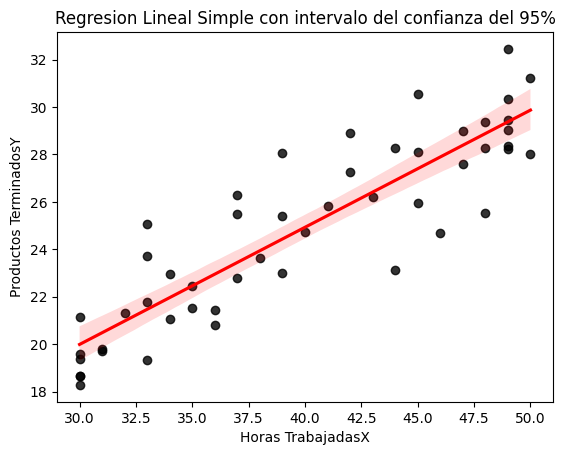

In [103]:
#GENERAR LA GRAFICA CON INTERVALOS
sns.regplot(x=df[variable_x], y=df[variable_y], ci=95, line_kws={"color":"red"}, scatter_kws={"color": "black"})

plt.title('Regresion Lineal Simple con intervalo del confianza del 95%')
plt.show()

In [ ]:
#GENERAR PREDICCION
dato_predictor = 10
horas_trabajadas_nuevas = pd.DataFrame([dato_predictor], columns=[variable_x])
autos_producidos_prediccion = modelo.predict(horas_trabajadas_nuevas)
print('La prediccion de autos producidos para', horas_trabajadas_nuevas.iloc[0][0] , 'Horas trabajadas es:', round(autos_producidos_prediccion[0],3))

La prediccion de autos producidos para 100 Horas trabajadas es: 54.578
